<div style="text-align:center; background-color:white; padding:20px; border-radius:10px;">

<h1 style="color:#1E5EFF; font-family:Comic Sans MS;">

</h1>

<img src="https://github.com/ajayvdatascience/image/blob/main/ChatGPT%20Image%20Jul%2026,%202026,%2008_13_42%20PM.png?raw=true"
     width="1000"
     style="border:3px solid #4CAF50; border-radius:15px;">

<p style="font-size:18px; color:gray;">

</p>

</div>



## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [82]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

**Necessary library**

* **NumPy (`numpy`)** – Used for numerical computations and array operations.
* **Pandas (`pandas`)** – Used for data loading, manipulation, and analysis.
* **Matplotlib (`matplotlib.pyplot`)** – Used for creating charts and plots.
* **Seaborn (`seaborn`)** – Used for statistical data visualization.
* **Gensim (`Word2Vec`)** – Used to generate word embeddings.
* **PyTorch (`torch`)** – Used for deep learning and tensor operations.
* **SentenceTransformers** – Used to create sentence embeddings.
* **Transformers** – Used to load pre-trained transformer models such as T5.
* **Scikit-learn (`train_test_split`)** – Used to split data into training and testing sets.
* **Scikit-learn (`RandomForestClassifier`)** – Used to build a Random Forest classification model.
* **Scikit-learn (`metrics`)** – Used to evaluate model performance using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
* **Warnings (`warnings`)** – Used to suppress unnecessary warning messages.
* **TensorFlow (`tensorflow`)** – Used for building deep learning models.
* **Keras (`keras`)** – High-level API for creating and training neural networks.
* **Sequential** – Used to build a sequential neural network model.
* **Dense** – Used to add fully connected neural network layers.
* **Dropout** – Used to reduce overfitting by randomly dropping neurons during training.


In [83]:
# To read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [84]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GEN AI DATASET/stock_news.csv")

In [86]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

Data overview is the process of understanding the dataset by examining its structure, features, size, and basic statistics before analysis.


###**Checking the first 5 rows**

In [87]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [88]:
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [89]:
data.shape

(349, 8)

###**Checking for missing values**

In [90]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [91]:
# checking for duplicate values
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
344,False
345,False
346,False
347,False


In [92]:
data.duplicated().sum()

0

## **Exploratory Data Analysis**

In [93]:
# To display the structure of data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [94]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [95]:
# To ensure the data type of Date
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


In [96]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

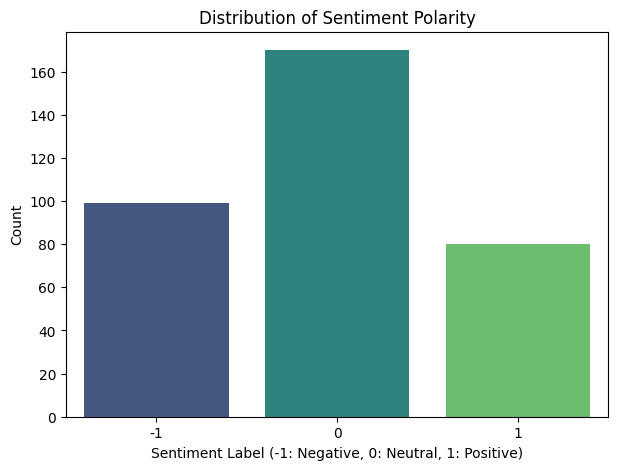

In [97]:
# Distribution of sentiment polarity
plt.figure(figsize=(7, 5))
sns.countplot(x='Label', data=data, palette='viridis')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Count')
plt.show()

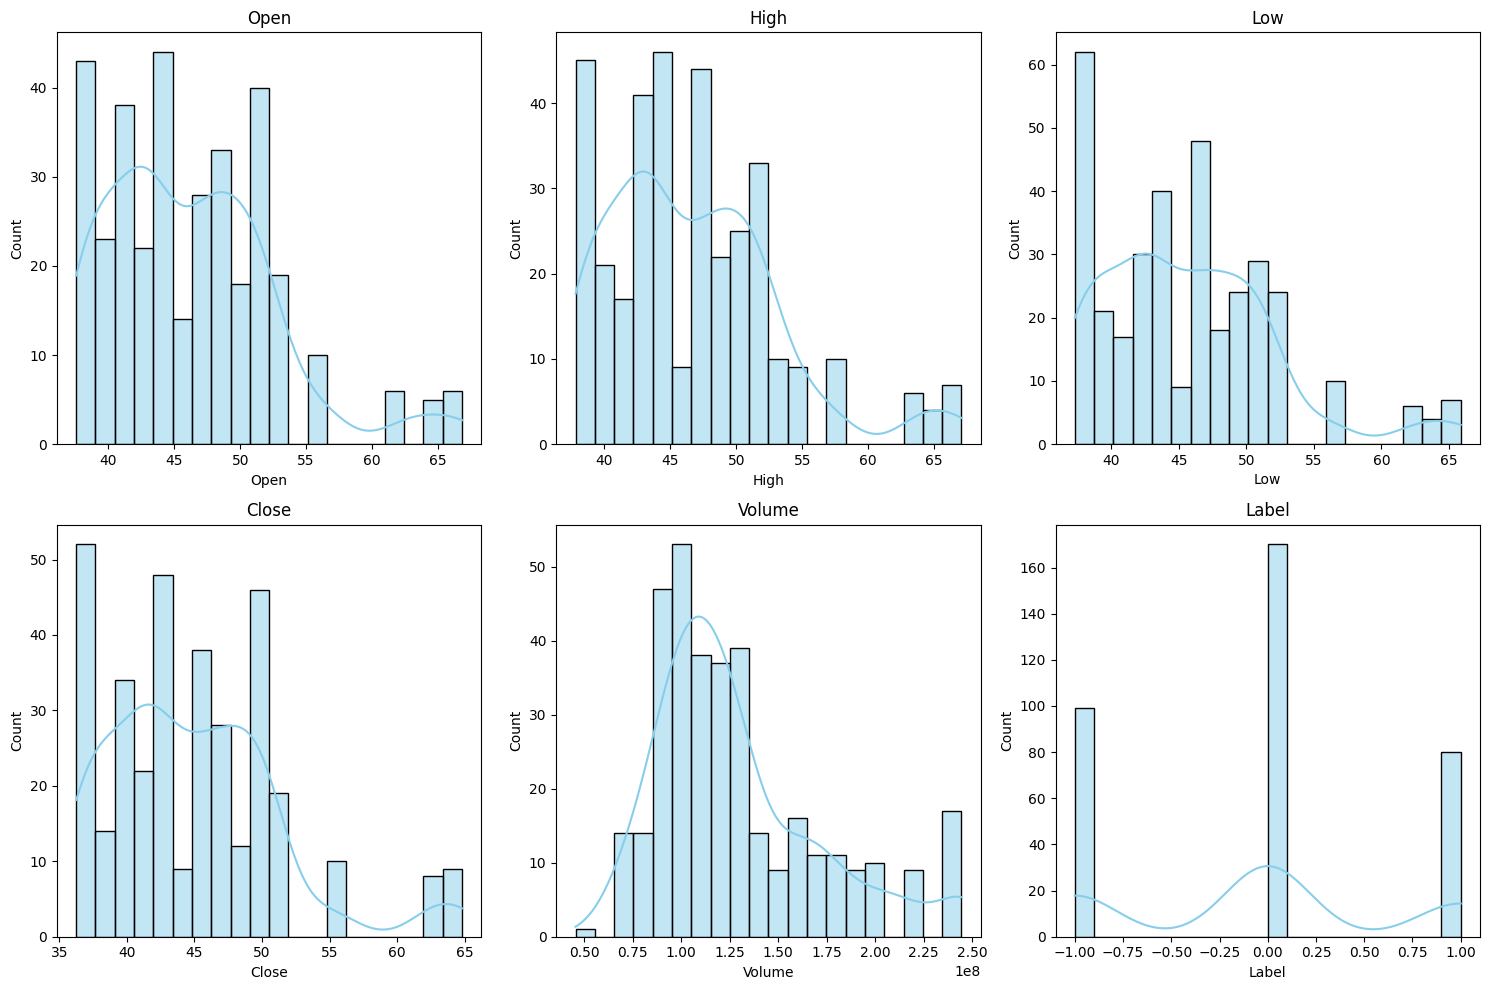

In [98]:
# Plot Distribution of all Numeric variables
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], bins=20, kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

### **Distribution of the length of news content**

In [99]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(x.split()))

# Summary statistics of news length
print(data['News_Length'].describe())

count    349.000000
mean      48.349570
std        5.717324
min       18.000000
25%       45.000000
50%       49.000000
75%       52.000000
max       60.000000
Name: News_Length, dtype: float64


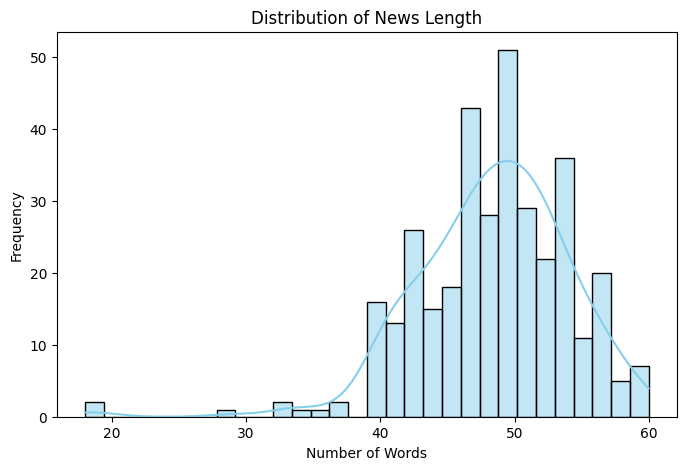

In [100]:
# Plot distribution
plt.figure(figsize=(8,5))
sns.histplot(data['News_Length'],
             bins=30,
             kde=True,
             color='skyblue')
plt.title("Distribution of News Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

### **Monthwise Analysis**

In [101]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


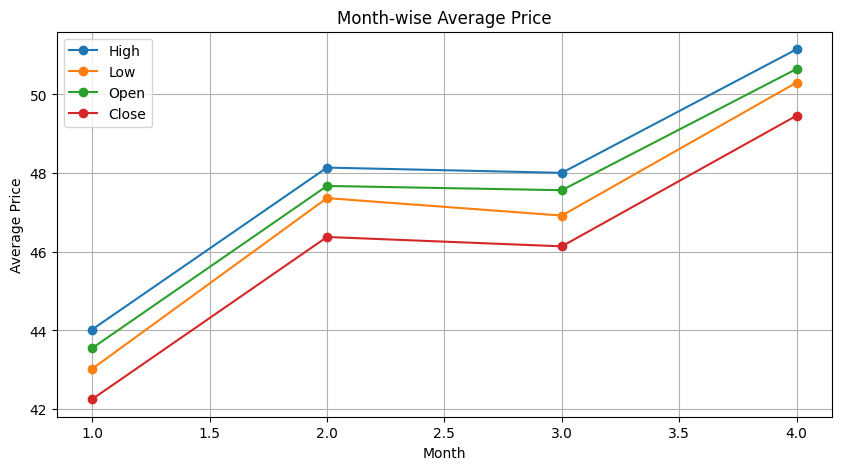

In [102]:
# plot the monthwise averages of all price variables for better visualization
monthly_avg = data.groupby(data['Date'].dt.month)[['High','Low','Open','Close']].mean()
# Plot
monthly_avg.plot(figsize=(10,5), marker='o')
plt.title("Month-wise Average Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

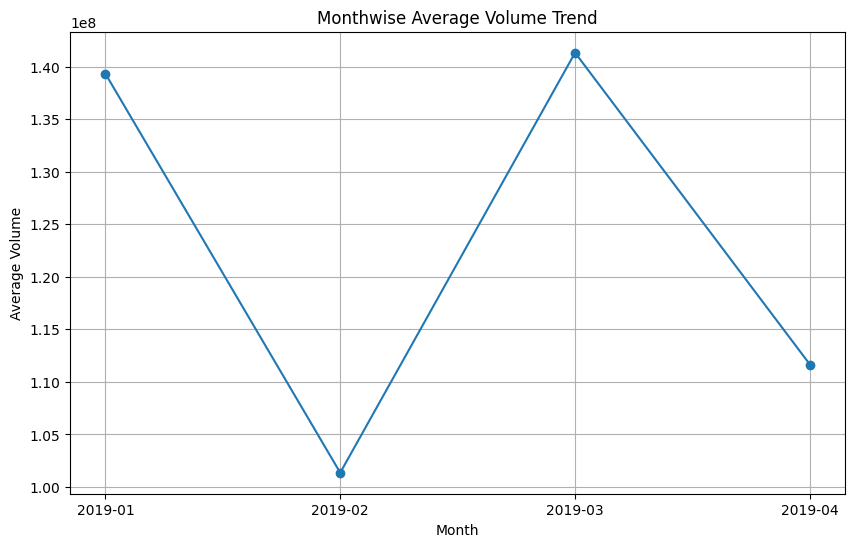

In [103]:


# Plot the trend of monthwise averages in Volume
plt.figure(figsize=(10, 6))
plt.plot(monthwise_avg['YearMonth'], monthwise_avg['Volume'], marker='o')
plt.title('Monthwise Average Volume Trend')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Average Volume')

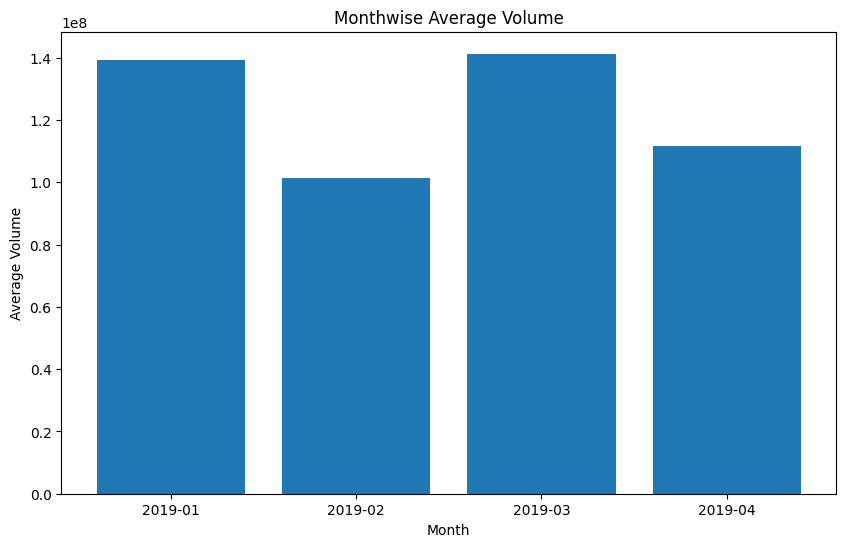

In [104]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(10, 6))
plt.bar(monthwise_avg['YearMonth'], monthwise_avg['Volume'])
plt.title('Monthwise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')


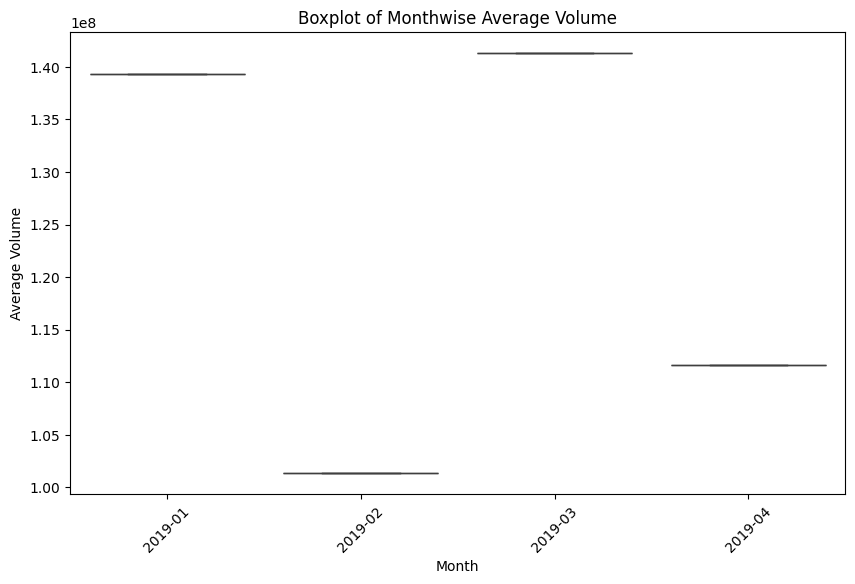

In [105]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='YearMonth', y='Volume', data=monthwise_avg)
plt.title('Boxplot of Monthwise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

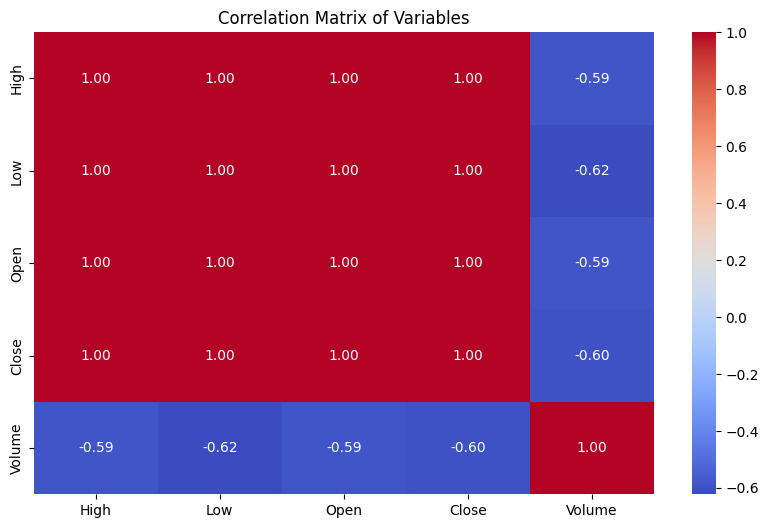

In [106]:
# Correlation matrix to check if variables move together or have correlations

plt.figure(figsize=(10, 6))
correlation = monthwise_avg.select_dtypes(include=['number']).corr()
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix of Variables')
plt.show()

**Interpretation:**

* **High Positive Correlation (0.8 to 1.0):**
  Variables have a strong relationship and move together.

* **Moderate Correlation (0.5 to 0.8):**
  Variables have a moderate relationship with each other.

* **Low Correlation (0 to 0.5):**
  Variables have a weak relationship and less dependency.

* **Negative Correlation (-1 to 0):**
  Variables move in opposite directions; one increases while the other decreases.



### **Sentiment Polarity vs Price**

Sentiment Polarity Correlation with Numeric Variables:

             Open  High   Low  Close  Volume  Label  News_Length
Open         1.00  1.00  1.00   1.00   -0.07   0.07         0.10
High         1.00  1.00  1.00   1.00   -0.05   0.07         0.10
Low          1.00  1.00  1.00   1.00   -0.10   0.06         0.10
Close        1.00  1.00  1.00   1.00   -0.08   0.06         0.09
Volume      -0.07 -0.05 -0.10  -0.08    1.00  -0.01        -0.00
Label        0.07  0.07  0.06   0.06   -0.01   1.00         0.00
News_Length  0.10  0.10  0.10   0.09   -0.00   0.00         1.00


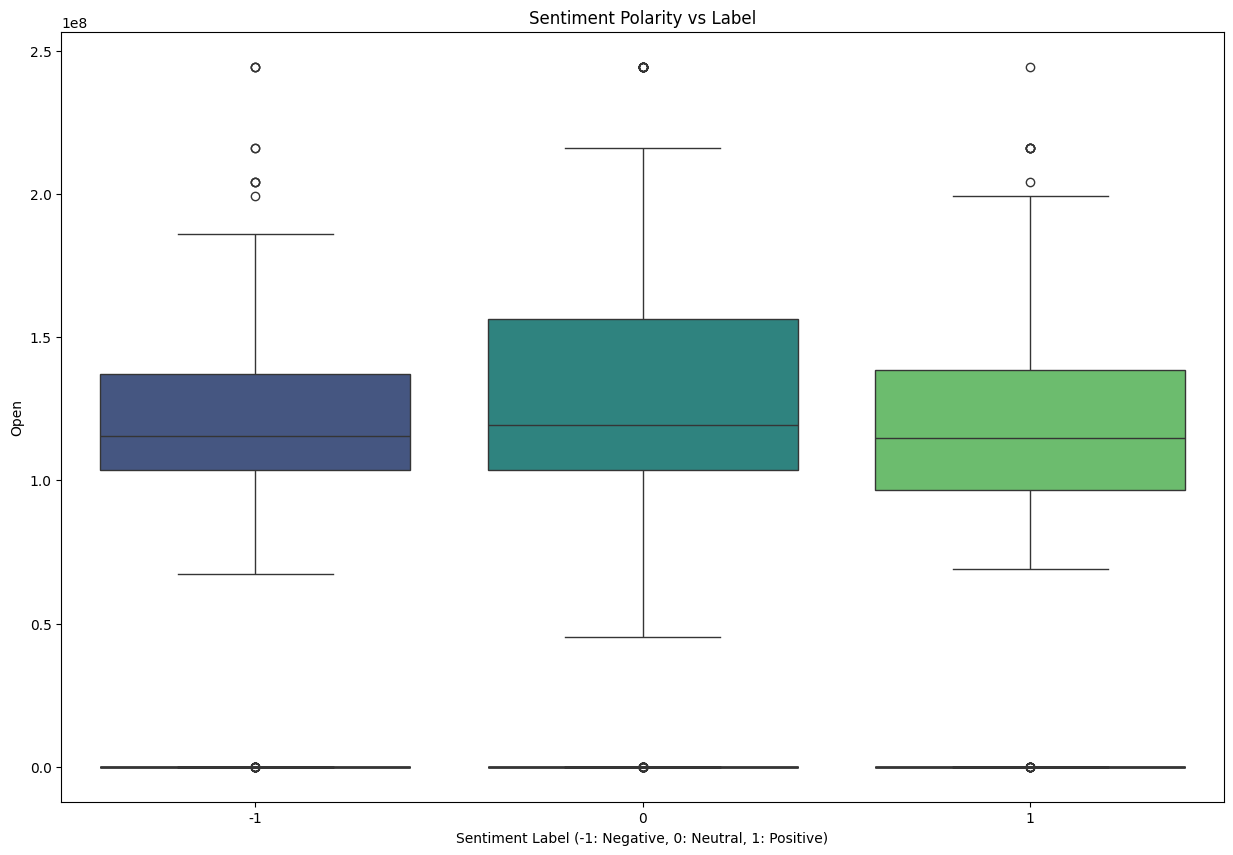

In [107]:
#Sentiment Polarity with all numeric variables
numeric_data = data.select_dtypes(include=['number'])

# Calculate correlation matrix
sentiment_corr = numeric_data.corr()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot()
    sns.boxplot(x='Label', y=col, data=data, palette='viridis')
    plt.title(f'Sentiment Polarity vs {col}')
    plt.xlabel('Sentiment Label (-1: Negative, 0: Neutral, 1: Positive)')
# Display correlation output
print("Sentiment Polarity Correlation with Numeric Variables:\n")
print(sentiment_corr.round(2))



**Interpretation:**

* Positive correlation → Variables increase together.
* Negative correlation → One variable increases while the other decreases.
* High correlation → Strong relationship between variables.
* Low correlation → Weak relationship between variables.
* Sentiment polarity has a positive impact on rating and sales.
* Price has a small negative effect on sentiment.


### **Time Series Analysis (Date vs Price)**

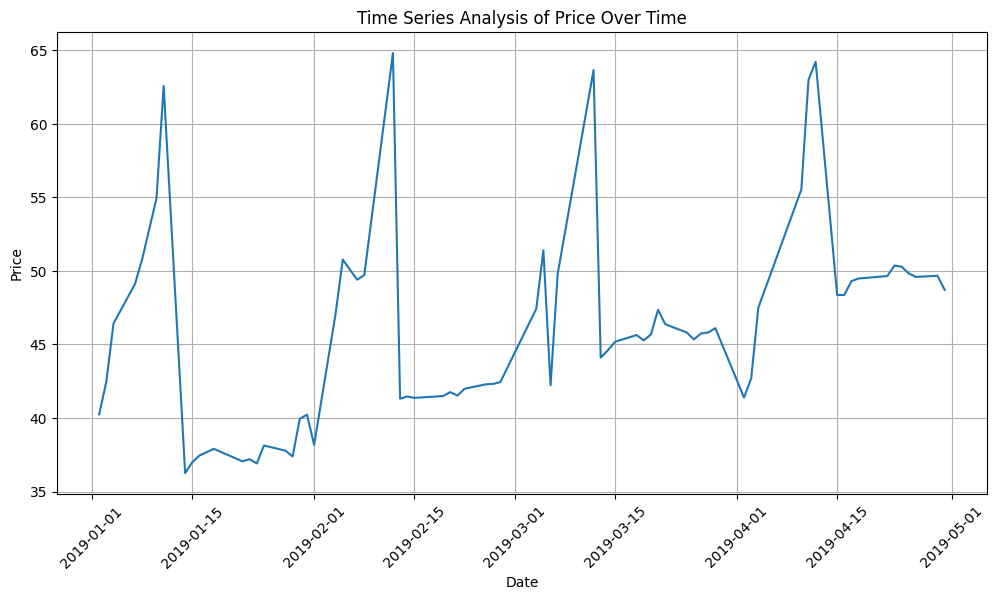

In [108]:
#Time Series Analysis (Date vs Price columns)

# Step-1: Convert Date column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Step-2: Sort data based on date
df = data.sort_values('Date')

# Step-3 :Time Series Analysis: Date vs Price
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'])
plt.title('Time Series Analysis of Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Interpretation:**

1.Shows how prices change over different time periods.

2.Helps identify increasing or decreasing price trends.

3.Helps detect sudden price changes and patterns.

4.Useful for forecasting future price movements.

### **Distribution of News Length Across Sentiment Categories**

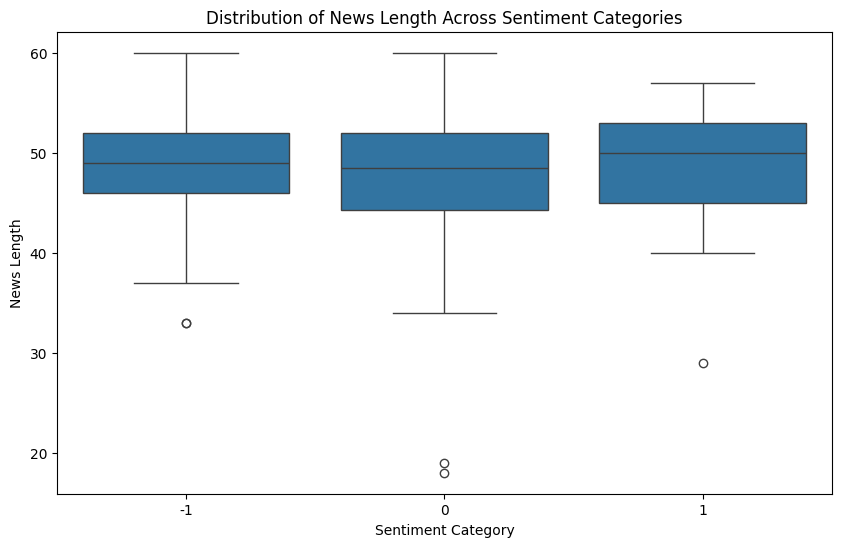

In [109]:
# Distribution of News Length Across Sentiment Categories

plt.figure(figsize=(10, 6))

sns.boxplot(x='Label', y='News_Length', data=df)

plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('News Length')

plt.show()



### **Interpretation:**

* **Positive Sentiment:** Shows the length distribution of positive news articles.
* **Negative Sentiment:** Shows the length distribution of negative news articles.
* **Neutral Sentiment:** Shows the length distribution of neutral news articles.
* Longer news articles may contain more detailed information.
* Differences in length across sentiment groups indicate variation in writing patterns.


## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [110]:
# Storing target variable
y = data['Label']



## **Word Embeddings**


#### **Word2Vec**

Step-1: Tokenize News

In [111]:
# Creating a list of all words in our data
tokenized_news = data['News'].apply(lambda x: x.split())

Step-2: Create a Single List of Words

In [112]:
all_words = [word for sublist in tokenized_news for word in sublist]

Step-3 : Training The Word2vec Model

In [113]:


vec_size = 100
word2vec_model = Word2Vec(
    sentences=tokenized_news,
    vector_size=vec_size,
    window=5,
    min_count=1,
    workers=4
)



Step-4: Count Total Words and Set Vector *Size*

In [114]:
print(f"Vocabulary size: {len(word2vec_model.wv)}")
print(f"Total number of words: {len(all_words)}")


Vocabulary size: 4681
Total number of words: 16874


Step-5: Retrieving word vectors for all the words present in the model's vocabulary

In [115]:
words = list(word2vec_model.wv.index_to_key)

Step-6: Creating a dictionary of words and their corresponding vectors

In [116]:
word_vector_dict = {word: word2vec_model.wv[word] for word in words}


Step-7: Print Values

In [117]:
print(f"Number of words with vectors: {len(word_vector_dict)}")


Number of words with vectors: 4681


In [118]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [119]:
# creating a dataframe of the vectorized documents
vectorized_docs = [average_vectorizer_Word2Vec(doc) for doc in data['News']]
vectorized_df = pd.DataFrame(vectorized_docs)

# Display the first 5 rows
vectorized_df.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.059505,0.072304,0.018067,-0.021970,0.022436,-0.109500,0.036547,0.165303,-0.074923,-0.051870,...,0.070132,0.014749,0.047590,0.008289,0.124673,0.044621,0.029137,-0.059846,0.022255,0.009117
1,-0.056247,0.070595,0.018323,-0.023297,0.022375,-0.105393,0.034021,0.158735,-0.073610,-0.049068,...,0.066208,0.014167,0.046633,0.006066,0.118202,0.043830,0.027914,-0.059009,0.021808,0.008305
2,-0.051383,0.064833,0.016832,-0.020092,0.021087,-0.098598,0.032147,0.146562,-0.068796,-0.045238,...,0.061853,0.013060,0.043265,0.005582,0.110815,0.041177,0.026036,-0.054274,0.020316,0.007929
3,-0.061818,0.073444,0.019909,-0.023878,0.023942,-0.111849,0.038634,0.166567,-0.079240,-0.051925,...,0.070175,0.014584,0.048116,0.006587,0.124696,0.047730,0.031349,-0.060205,0.023238,0.008734
4,-0.058040,0.071356,0.017391,-0.022017,0.022852,-0.106166,0.033845,0.160287,-0.075020,-0.049534,...,0.066501,0.014353,0.047533,0.006676,0.122126,0.044149,0.030348,-0.059482,0.020770,0.009870


**Word2vec Workflow**

</h1>

<img src="https://github.com/ajayvdatascience/image/blob/main/00ac721b-ea97-4339-9e9f-7e4988734b13.png?raw=true"
     width="1000"
     style="border:2px solid #4CAF50; border-radius:15px;">

<p style="font-size:15px; color:gray;">

</p>

</div>

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [120]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

##### Encoding the dataset

In [121]:
embedding_matrix = model.encode(data['News'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [122]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [123]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [124]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [125]:
# Storing independent variable
X = vectorized_df

In [126]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [127]:
# Building the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting on train data
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [128]:
# Predicting on train data
y_pred_train = model.predict(X_train)

# Predicting on test data
y_pred_test = model.predict(X_test)

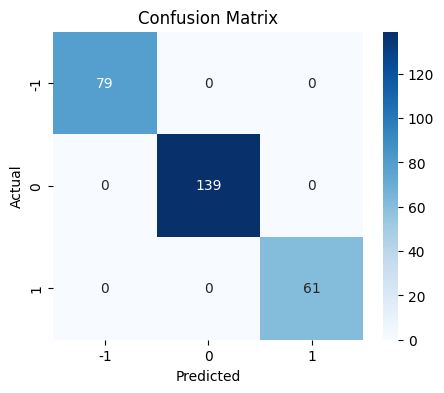

In [129]:
plot_confusion_matrix(y_train, y_pred_train)

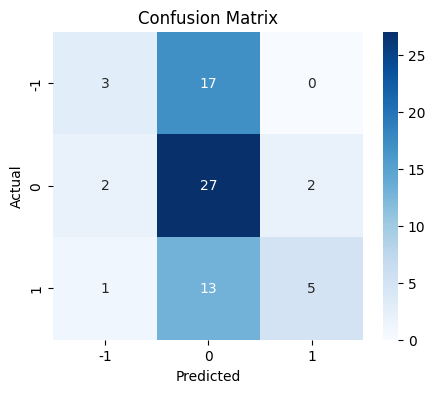

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


In [158]:
plot_confusion_matrix(y_test, y_pred_test)
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

###**Sentence Transformer-Random Forest Model**

In [159]:
# Storing independent variable
X = embedding_matrix


In [160]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [161]:
# Building the model
model = RandomForestClassifier(n_estimators=100, random_state=42)


# Fitting on train data
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [162]:
# Predicting on train data
y_pred_train = model.predict(X_train)

# Predicting on test data
y_pred_test = model.predict(X_test)

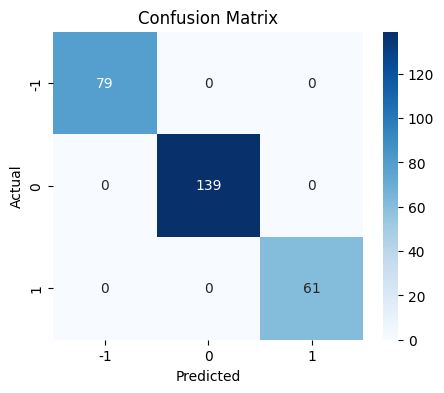

In [163]:
plot_confusion_matrix(y_train, y_pred_train)

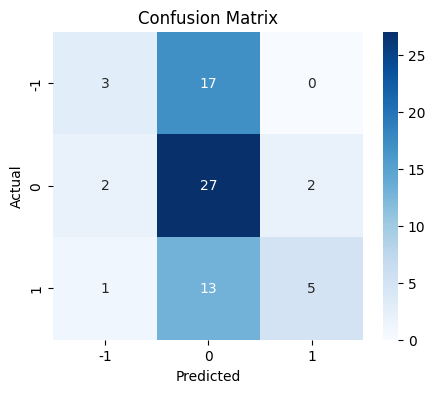

In [164]:
plot_confusion_matrix(y_test, y_pred_test)

In [165]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


## **Random Forest Models Workflow**



<div align="center">
  <img src="https://github.com/ajayvdatascience/image/blob/main/705b4e03-ea5a-44d9-8f45-8bac85dae71c.png?raw=true" width="700">
</div>


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [166]:
# Storing independent variable
X = X

In [168]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [169]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [170]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax')) # 3 output neurons for 3 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [171]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 623ms/step - accuracy: 0.4373 - loss: 1.0832 - val_accuracy: 0.4429 - val_loss: 1.0674
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4982 - loss: 1.0327 - val_accuracy: 0.4429 - val_loss: 1.0582
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4946 - loss: 1.0034 - val_accuracy: 0.4429 - val_loss: 1.0460
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5161 - loss: 0.9874 - val_accuracy: 0.4429 - val_loss: 1.0195
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5376 - loss: 0.9289 - val_accuracy: 0.4714 - val_loss: 0.9905
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5842 - loss: 0.8766 - val_accuracy: 0.4857 - val_loss: 0.9578
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5878 - loss: 0.8524 - val_accuracy: 0.5714 - val_loss: 0.9210
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6380 - loss: 0.7855 - val_accuracy: 0.5429 - val_loss: 0.920

In [143]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step


In [172]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


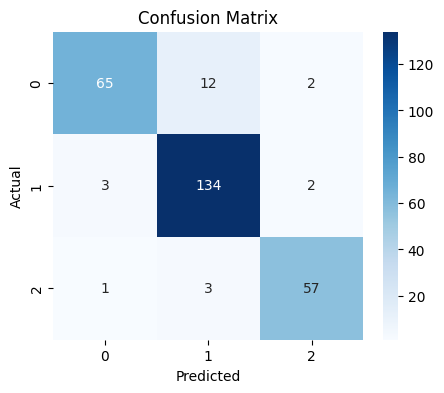

In [173]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

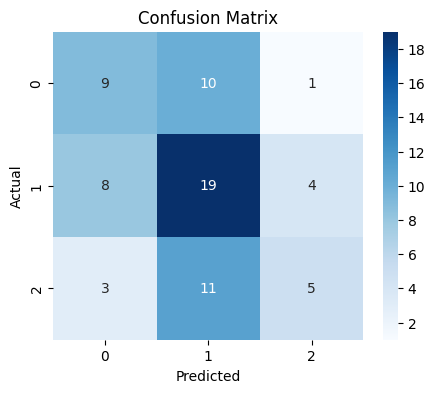

In [174]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [175]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.917563 0.917563   0.919093 0.916628
Test set performance metrics:
 Accuracy   Recall  Precision      F1
 0.471429 0.471429   0.474643 0.45919


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [176]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [177]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [178]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax')) # 3 output neurons for 3 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [179]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 455ms/step - accuracy: 0.4337 - loss: 1.0753 - val_accuracy: 0.4429 - val_loss: 1.0650
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0425 - val_accuracy: 0.4429 - val_loss: 1.0650
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0149 - val_accuracy: 0.4429 - val_loss: 1.0504
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5018 - loss: 0.9752 - val_accuracy: 0.4429 - val_loss: 1.0378
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5054 - loss: 0.9614 - val_accuracy: 0.4429 - val_loss: 1.0128
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5735 - loss: 0.9024 - val_accuracy: 0.5000 - val_loss: 0.9867
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5341 - loss: 0.8712 - val_accuracy: 0.5000 - val_loss: 0.9583
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6237 - loss: 0.8179 - val_accuracy: 0.5286 - val_loss: 0.9442

In [152]:
# Predict class probabilities on training data
y_train_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step


In [153]:
# Predict class probabilities on test data
y_test_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


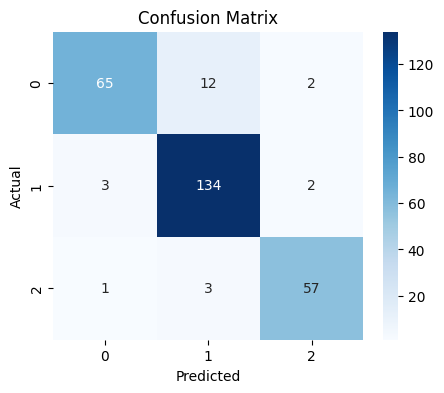

In [154]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

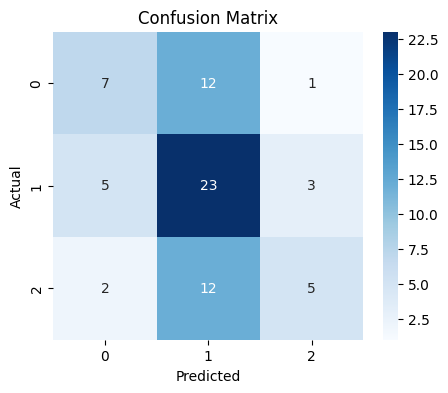

In [155]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [156]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.917563 0.917563   0.919093 0.916628
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.510368 0.475758


### **Model Performance Summary and Final Model Selection**

In [180]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
     [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings

    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",

]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.917563,1.0,0.917563
Recall,1.0,0.917563,1.0,0.917563
Precision,1.0,0.919093,1.0,0.919093
F1,1.0,0.916628,1.0,0.916628


In [181]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",

]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.500000,0.471429,0.500000,0.500000
Recall,0.500000,0.471429,0.500000,0.500000
Precision,0.546509,0.474643,0.546509,0.510368
F1,0.442083,0.459190,0.442083,0.475758


## **Conclusions and Recommendations**

In [182]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.500000,0.471429,0.500000,0.500000
Recall,0.500000,0.471429,0.500000,0.500000
Precision,0.546509,0.474643,0.546509,0.510368
F1,0.442083,0.459190,0.442083,0.475758


In [183]:
print("Training performance comparison:")
display(models_train_comp_df)

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.917563,1.0,0.917563
Recall,1.0,0.917563,1.0,0.917563
Precision,1.0,0.919093,1.0,0.919093
F1,1.0,0.916628,1.0,0.916628


In [184]:
print("Test performance comparison:")
display(models_test_comp_df)

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.500000,0.471429,0.500000,0.500000
Recall,0.500000,0.471429,0.500000,0.500000
Precision,0.546509,0.474643,0.546509,0.510368
F1,0.442083,0.459190,0.442083,0.475758


**WorkFlow**

<div align="center">
  <img src="https://github.com/ajayvdatascience/image/blob/main/c44a66cb-0098-40db-b254-4b6bcfbc4b57.png?raw=true" width="700">
</div>

#### **Conclusions**

**Word2Vec**

**Sentence Transformer embeddings**

**Neural Networks**

**Random Forest**



#### **Recommendations**



1. **Use Sentence Transformer embeddings** because they understand the meaning of news better than Word2Vec.

2. **Use the Random Forest model** because it achieved the best test performance in this project.

3. **Collect more news articles** to improve the model's learning and prediction accuracy.

4. **Use real-time stock market data** to make predictions more reliable.

5. **Add more features** such as company financial data and technical indicators.

6. **Clean and preprocess the text properly** by removing noise and unnecessary words.

7. **Tune the model parameters** to improve overall performance.

8. **Use financial language models** like FinBERT for better sentiment analysis.

9. **Validate the model using cross-validation** to ensure stable performance.

10. **Deploy the model** using Streamlit or Flask so users can analyze news in real time.

11. **Retrain the model regularly** with new stock news to keep it updated.

12. **Monitor model performance** continuously and improve it when accuracy decreases.

13. **Use the model to support investment decisions**, not as the only decision-making tool.

14. **Compare multiple machine learning models** before selecting the final model.

15. **Continue improving the dataset quality** because better data leads to better predictions.




